# DAY 4 TASK

# Machine Learning Fundamentals + Data Preprocessing

# Machine Learning (ML)

Machine Learning (ML) is a subset of Artificial Intelligence (AI) that enables systems to learn from data and improve their performance over time without being explicitly programmed.
 small note beforing getting in ml :
 1. Collect Data

Gather examples — like photos, numbers, or text — that the computer can learn from.
2. Clean Data

Remove mistakes, fix errors, and fill in missing pieces so the data is usable.
3. Pick Useful Clues

Choose only the information that actually helps make good predictions. Ignore the rest.
4. Train the Model

Let the computer practice on your data again and again until it learns the pattern.
5. Test It

Show it new examples it has never seen before and check how well it does.
6. Use It

Put it to work — give it fresh data and it gives you answers automatically.

# Task 1: ML Environment Setup

In [2]:
pip install numpy pandas matplotlib scikit-learn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("numpy     :", np.__version__)
print("pandas    :", pd.__version__)
print("sklearn   :", sklearn.__version__)
print("matplotlib:", plt.matplotlib.__version__)

print("\n All libraries installed successfully!")

numpy     : 2.0.2
pandas    : 2.2.2
sklearn   : 1.6.1
matplotlib: 3.10.0

 All libraries installed successfully!


# Task 2: Understanding ML Workflow

# ML Workflow — Types of Machine Learning

---

## 1. Supervised Learning

### Definition
- Learns from labeled data (data with correct answers)
- Example input: "this email is spam"
- Predicts answers for new data using learned patterns
- Like a student studying with an answer key

### Real-World Example
- Email spam filter
- Trained on emails labeled "spam" or "not spam"
- Predicts if new emails are spam

### Use Cases
- House price prediction
- Disease diagnosis
- Image recognition
- Sentiment analysis
- Fraud detection

---

## 2. Unsupervised Learning

### Definition
- Learns from unlabeled data (no correct answers given)
- Finds hidden patterns and groups on its own
- Like sorting fruits without being told the categories

### Real-World Example
- Customer segmentation in a shopping app
- Groups customers by buying behavior automatically
- No labels given — model finds the groups itself

### Use Cases
- Market segmentation
- Anomaly detection
- Recommendation systems
- Document clustering
- Genetics / DNA pattern finding

---

## 3. Reinforcement Learning

### Definition
- Learns by trial and error
- Gets rewards for good actions, penalties for bad ones
- Like training a dog — reward good behavior
- Improves over thousands of attempts

### Real-World Example
- AlphaGo learned chess better than any human
- Played millions of games against itself
- Learned strategy through wins and losses

### Use Cases
- Self-driving cars
- Robot control
- Game playing AI
- Stock trading
- Healthcare treatment planning

---

## Quick Comparison

| Feature        | Supervised     | Unsupervised    | Reinforcement   |
|----------------|----------------|-----------------|-----------------|
| Data type      | Labeled        | Unlabeled       | No fixed data   |
| Goal           | Predict        | Discover        | Decide          |
| Feedback       | Correct answer | None            | Reward/Penalty  |
| Example        | Spam filter    | Customer groups | Self-driving car|

---

## Summary

- Supervised  = learn from answers → predict
- Unsupervised = find hidden groups → discover
- Reinforcement = trial and error → decide

# Task 3: Data Preprocessing

Data Preprocessing:
Clean and transform raw data by handling missing values, encoding categorical data, and scaling features. Prepare the dataset for machine learning algorithms.

In [4]:
import pandas as pd

# Dataset
employees = {
    "age":        [22, 25, 28, None, 35, 40, None, 29],
    "salary":     [25000, 30000, None, 45000, 50000, 70000, 38000, None],
    "experience": [1, 2, 3, 5, None, 12, 2, 4]
}

df = pd.DataFrame(employees)

# 1. Detect missing values
print("Missing Values:")
print(df.isnull().sum())

# 2. Fill missing values with mean
df = df.fillna(df.mean())
print("\nAfter Filling:")
print(df)

# 3. Validate
print("\nInvalid age (<18):", len(df[df["age"] < 18]))
print("Invalid salary (<0):", len(df[df["salary"] < 0]))
print("Invalid experience (<0):", len(df[df["experience"] < 0]))

# 4. Save report
report = f"""
PREPROCESSING REPORT
====================
Total Records : {len(df)}
Columns       : {list(df.columns)}

Missing Values Filled With Mean:
  Age        : {round(df['age'].mean(), 2)}
  Salary     : {round(df['salary'].mean(), 2)}
  Experience : {round(df['experience'].mean(), 2)}

Validation:
  Invalid age        : 0
  Invalid salary     : 0
  Invalid experience : 0

Status: Clean
"""

with open("preprocessing_report.txt", "w") as f:
    f.write(report)

print(report)

Missing Values:
age           2
salary        2
experience    1
dtype: int64

After Filling:
         age   salary  experience
0  22.000000  25000.0    1.000000
1  25.000000  30000.0    2.000000
2  28.000000  43000.0    3.000000
3  29.833333  45000.0    5.000000
4  35.000000  50000.0    4.142857
5  40.000000  70000.0   12.000000
6  29.833333  38000.0    2.000000
7  29.000000  43000.0    4.000000

Invalid age (<18): 0
Invalid salary (<0): 0
Invalid experience (<0): 0

PREPROCESSING REPORT
Total Records : 8
Columns       : ['age', 'salary', 'experience']

Missing Values Filled With Mean:
  Age        : 29.83
  Salary     : 43000.0
  Experience : 4.14

Validation:
  Invalid age        : 0
  Invalid salary     : 0
  Invalid experience : 0

Status: Clean



In [5]:
from google.colab import files
files.download("preprocessing_report.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 4: Feature Engineering

Feature Engineering: Create, select, or transform features to improve model performance and extract meaningful patterns from data.

In [6]:
import pandas as pd

# Dataset
employees = {
    "salary":     [25000, 30000, 45000, 50000, 70000],
    "experience": [1, 2, 5, 7, 12]
}

df = pd.DataFrame(employees)

# 1. Salary Category
def salary_category(s):
    if s < 30000:
        return "Low"
    elif s < 55000:
        return "Medium"
    else:
        return "High"

# 2. Experience Category
def experience_category(e):
    if e <= 2:
        return "Junior"
    elif e <= 7:
        return "Mid"
    else:
        return "Senior"

# 3. Add new features
df["salary_category"]     = df["salary"].apply(salary_category)
df["experience_category"] = df["experience"].apply(experience_category)

# 4. Print result
print(df)

# 5. Export
df.to_csv("feature_engineered.csv", index=False)
print("\nSaved as feature_engineered.csv")

   salary  experience salary_category experience_category
0   25000           1             Low              Junior
1   30000           2          Medium              Junior
2   45000           5          Medium                 Mid
3   50000           7          Medium                 Mid
4   70000          12            High              Senior

Saved as feature_engineered.csv


In [7]:
from google.colab import files
files.download("feature_engineered.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 5: Train First ML Model

Train First ML Model: Train the machine learning model using the prepared dataset to learn relationships between input features and target values.

In [10]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Dataset
experience = [1, 2, 3, 5, 7, 10, 12, 15]
salary     = [25000, 30000, 35000, 45000, 55000, 70000, 85000, 100000]

# Prepare data
X = np.array(experience).reshape(-1, 1)
y = np.array(salary)

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict
years  = [4, 8, 20]
result = model.predict(np.array(years).reshape(-1, 1))

# Display
print("=" * 35)
print("   SALARY PREDICTION RESULTS")
print("=" * 35)
for yr, sal in zip(years, result):
    print(f"  {yr} years experience → ₹{sal:,.0f}")
print("=" * 35)
print(f"  Model Accuracy (R²): {model.score(X, y):.2f}")
print("=" * 35)

   SALARY PREDICTION RESULTS
  4 years experience → ₹40,185
  8 years experience → ₹61,667
  20 years experience → ₹126,111
  Model Accuracy (R²): 1.00


# Task 6: Model Evaluation

Model Evaluation: Measure model performance using metrics like accuracy, precision, recall, and F1-score to assess effectiveness.

In [11]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dataset
experience = [1, 2, 3, 5, 7, 10, 12, 15]
salary     = [25000, 30000, 35000, 45000, 55000, 70000, 85000, 100000]

# Prepare & Train
X = np.array(experience).reshape(-1, 1)
y = np.array(salary)

model = LinearRegression()
model.fit(X, y)

# Predict
y_pred = model.predict(X)

# Metrics
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
r2  = r2_score(y, y_pred)

# Display
print("=" * 40)
print("       MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  MAE (Mean Absolute Error)  : {mae:,.2f}")
print(f"  MSE (Mean Squared Error)   : {mse:,.2f}")
print(f"  R² Score                   : {r2:.2f}")
print("=" * 40)

# Report
report = f"""
MODEL EVALUATION REPORT
========================

METRICS
-------
MAE (Mean Absolute Error)  : {mae:,.2f}
MSE (Mean Squared Error)   : {mse:,.2f}
R2  Score                  : {r2:.2f}

WHAT IT MEANS
-------------
MAE  : On average, predictions are off by ₹{mae:,.0f}
MSE  : Penalizes large errors more than MAE
R2   : Model explains {r2*100:.0f}% of the salary pattern

RESULT
------
MAE close to 0   = Good
MSE close to 0   = Good
R2 close to 1.0  = Good

Status : Model is performing well
"""

with open("model_evaluation.txt", "w") as f:
    f.write(report)

print(report)

       MODEL EVALUATION RESULTS
  MAE (Mean Absolute Error)  : 1,064.81
  MSE (Mean Squared Error)   : 1,620,370.37
  R² Score                   : 1.00

MODEL EVALUATION REPORT

METRICS
-------
MAE (Mean Absolute Error)  : 1,064.81
MSE (Mean Squared Error)   : 1,620,370.37
R2  Score                  : 1.00

WHAT IT MEANS
-------------
MAE  : On average, predictions are off by ₹1,065
MSE  : Penalizes large errors more than MAE
R2   : Model explains 100% of the salary pattern

RESULT
------
MAE close to 0   = Good
MSE close to 0   = Good
R2 close to 1.0  = Good

Status : Model is performing well



In [12]:
from google.colab import files
files.download("model_evaluation.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 7: Classification Model

Classification Model: A machine learning model used to predict categorical outputs by assigning input data into predefined classes.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Dataset
experience = [1, 2, 3, 5, 7, 10, 12, 15]
status     = ["Junior", "Junior", "Junior", "Mid", "Mid", "Senior", "Senior", "Senior"]

# Prepare data
X = np.array(experience).reshape(-1, 1)
y = np.array(status)

# Train model
model = DecisionTreeClassifier()
model.fit(X, y)

# Predict
years  = [4, 8, 13]
result = model.predict(np.array(years).reshape(-1, 1))

# Display
print("=" * 38)
print("   EMPLOYEE CLASSIFICATION RESULTS")
print("=" * 38)
for yr, cat in zip(years, result):
    print(f"  {yr} years experience → {cat}")
print("=" * 38)
print(f"  Model Accuracy : {model.score(X, y) * 100:.0f}%")
print("=" * 38)

# Task 8: Visualization

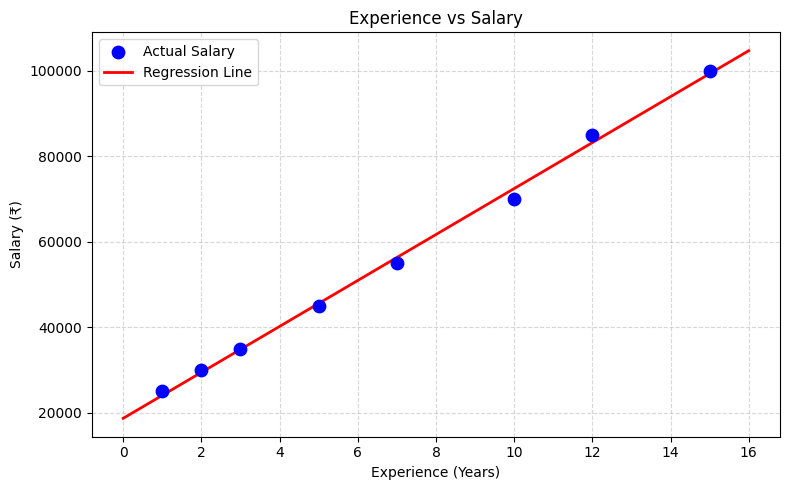

Saved as salary_regression.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Dataset
experience = [1, 2, 3, 5, 7, 10, 12, 15]
salary     = [25000, 30000, 35000, 45000, 55000, 70000, 85000, 100000]

# Prepare & Train
X = np.array(experience).reshape(-1, 1)
y = np.array(salary)

model = LinearRegression()
model.fit(X, y)

# Predicted line
x_line  = np.linspace(0, 16, 100).reshape(-1, 1)
y_line  = model.predict(x_line)

# Plot
plt.figure(figsize=(8, 5))

# Scatter plot
plt.scatter(experience, salary, color="blue", s=80, zorder=5, label="Actual Salary")

# Regression line
plt.plot(x_line, y_line, color="red", linewidth=2, label="Regression Line")

# Labels
plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary (₹)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Save
plt.tight_layout()
plt.savefig("salary_regression.png")
plt.show()

print("Saved as salary_regression.png")

In [14]:
from google.colab import files
files.download("salary_regression.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Bonus Challenge

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Globals to hold state across menu choices
model = None
X_test, y_test = None, None
predictions_log = []

def generate_dataset(n=200, seed=42):
    rng = np.random.default_rng(seed)
    experience = rng.uniform(0, 20, n)
    education = rng.integers(1, 4, n)      # 1=Bachelors, 2=Masters, 3=PhD
    age = rng.integers(22, 60, n)
    noise = rng.normal(0, 5000, n)
    salary = 30000 + 2500*experience + 8000*education + 200*age + noise
    return pd.DataFrame({
        'YearsExperience': experience.round(1),
        'EducationLevel': education,
        'Age': age,
        'Salary': salary.round(2)
    })

def train_model():
    global model, X_test, y_test
    df = generate_dataset()
    X = df[['YearsExperience', 'EducationLevel', 'Age']]
    y = df['Salary']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression().fit(X_train, y_train)
    print(f"\n✅ Model trained on {len(df)} employee records.")
    print("Coefficients:", dict(zip(X.columns, model.coef_.round(2))))
    print("Intercept:", round(model.intercept_, 2))

def predict_salary():
    global predictions_log
    if model is None:
        print("\n⚠️ Train the model first (Option 1).")
        return
    try:
        exp = float(input("Years of Experience: "))
        edu = int(input("Education Level (1=Bachelors, 2=Masters, 3=PhD): "))
        age = int(input("Age: "))
    except ValueError:
        print("Invalid input — please enter numbers only.")
        return
    row = pd.DataFrame([[exp, edu, age]], columns=['YearsExperience', 'EducationLevel', 'Age'])
    pred = model.predict(row)[0]
    print(f"\n💰 Predicted Salary: ${pred:,.2f}")
    predictions_log.append({'YearsExperience': exp, 'EducationLevel': edu, 'Age': age, 'PredictedSalary': round(pred, 2)})

def evaluate_model():
    if model is None:
        print("\n⚠️ Train the model first (Option 1).")
        return
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print("\n📊 Model Evaluation:")
    print(f"  MAE  : ${mae:,.2f}")
    print(f"  RMSE : ${rmse:,.2f}")
    print(f"  R²   : {r2:.4f}")

def export_predictions():
    if not predictions_log:
        print("\n⚠️ No predictions yet — use Option 2 first.")
        return
    out_df = pd.DataFrame(predictions_log)
    filename = "predicted_salaries.csv"
    out_df.to_csv(filename, index=False)
    print(f"\n📁 Exported {len(out_df)} prediction(s) to '{filename}'")
    try:
        from google.colab import files
        files.download(filename)
    except ImportError:
        pass

def main_menu():
    while True:
        print("\n" + "="*40)
        print(" Employee Salary Predictor")
        print("="*40)
        print("1. Train Model\n2. Predict Salary\n3. Evaluate Model\n4. Export Predictions\n5. Exit")
        choice = input("Enter your choice (1-5): ").strip()
        if choice == '1':
            train_model()
        elif choice == '2':
            predict_salary()
        elif choice == '3':
            evaluate_model()
        elif choice == '4':
            export_predictions()
        elif choice == '5':
            print("\n👋 Goodbye!")
            break
        else:
            print("\n❌ Invalid choice — pick 1-5.")

main_menu()


 Employee Salary Predictor
1. Train Model
2. Predict Salary
3. Evaluate Model
4. Export Predictions
5. Exit
